# Pyomo Übung 2

### Dynamischer Stromtarif mit Heimspeicher

Da seit 2025 dynamische Stromtarife verpflichtend angeboten werden müssen, überlegen Sie ihren Tarif zu einen solchen zu wechseln. Um Ihren Verbrauch zu flexibilisieren wollen Sie sich einen Lithium-Ionen-Heimspeicher zulegen. Ihnen liegen die Strompreise für 2024 stündlich aufgeschlüsselt, sowie der Stromverbrauch ihres Eigenheims vor. Bestimmen Sie die ökonomisch optimale Größe des Heimspeichers.

Die Kosten für den Heimspeicher können mit 750 €/kWh angenommen werden. Die Lebenszeit beträgt 20 Jahre, der Zinssatz kann mit 2% angenommen werden. Die _round trip_ Effizienz beträgt 95%. Standverluste können vernachlässigt werden.

Importieren Sie zunächst die notwendigen Bibliotheken

In [20]:
import pyomo.environ as pyo
import pandas as pd

Lesen Sie die Strompreise sowie Netzlast ein

In [21]:
df_data = pd.read_csv('data_Pyomo_2.csv')
df_strompreis = df_data['Strompreis [Euro/kWh]']
df_last = df_data['Netzlast [kW]']

Berechnen Sie die Stromkosten ohne Heimspeicher

In [22]:
ref_kosten = sum(df_last* df_strompreis)
print(round(ref_kosten, 2), '€')

1243.5 €


Bauen Sie ein Modell auf, welches die Problemstellung abbildet

In [27]:
# Modell und Set definieren
model = pyo.ConcreteModel(name = 'Heimspeicher')
model.T = pyo.Set(initialize = range(0,8784))

#Paramter

model.par_strompreis = pyo.Param(model.T, initialize=df_strompreis, 
                                 name= 'Strompreis in €/kWh')
model.par_last = pyo.Param(model.T, initialize=df_last, 
                                 name= 'Last in kW')
model.par_zinssatz = pyo.Param(initialize = 0.02, name = 'Zinssatz')
model.par_batterie_lebensdauer = pyo.Param(initialize=20, 
                                               name = 'Lebensdauer in Jahren')
model.par_batterie_kosten = pyo.Param(initialize = 750*((1+model.par_zinssatz)**model.par_batterie_lebensdauer)*model.par_zinssatz/((1+model.par_zinssatz)**model.par_batterie_lebensdauer-1), 
                                               name = 'spezifische Annuität des Batteriespeichers in €/(kWh*a)')
model.par_batterie_wirkungsgrad = pyo.Param(initialize = 0.95, 
                                               name = 'Ladeverluste der Batterie')

#Variablen definiern
model.var_batterie_kapazitaet = pyo.Var(within = pyo.NonNegativeReals, 
                                        name='Batteriespeichergröße in kWh')
model.var_batterie_fuellstand      = pyo.Var(model.T, within = pyo.NonNegativeReals, 
                                             name='Batteriebeladung in kWh')
model.var_netzbezug                = pyo.Var(model.T, within = pyo.NonNegativeReals, 
                                             name='Netzbezug in kW')
model.var_batterie_ladeleistung    = pyo.Var(model.T, within = pyo.NonNegativeReals, 
                                             name='Ladeleistung der Batterie')
model.var_batterie_entladeleistung = pyo.Var(model.T, within = pyo.NonNegativeReals, 
                                             name='Entladeleistung der Batterie')

# Zielfunktion
def Zielfunktion(model):
    target = (sum(model.var_netzbezug[t] * model.par_strompreis[t] for t in model.T) 
             + model.var_batterie_kapazitaet * model.par_batterie_kosten)
    return target

model.obj = pyo.Objective(rule = Zielfunktion, sense = pyo.minimize)

#Nebenbedingungen
def rule_lastdeckung(model, t):
    bedingung = model.par_last[t] == (model.var_netzbezug[t] - 
                                      model.var_batterie_ladeleistung[t] +
                                      model.var_batterie_entladeleistung[t])
    return bedingung
model.con_lastdeckung = pyo.Constraint(model.T, rule = rule_lastdeckung, 
                                       name = 'Leistungsbilanz')

def rule_limit_fuellstand(model, t):
    bedingung = model.var_batterie_fuellstand[t] <= model.var_batterie_kapazitaet
    return bedingung
model.con_fuellstand_limit = pyo.Constraint(model.T, rule = rule_limit_fuellstand, 
                                       name = 'Begrenzung Fuellstand') 


def rule_fuellstand(model, t):
    if t == 0:
        bedingung = model.var_batterie_fuellstand[t] == 0
    else:
        bedingung = model.var_batterie_fuellstand[t] == (model.var_batterie_fuellstand[t-1] +
                                                         model.var_batterie_ladeleistung[t] *
                                                         model.par_batterie_wirkungsgrad ** 0.5 -
                                                         model.var_batterie_entladeleistung[t] / 
                                                         model.par_batterie_wirkungsgrad ** 0.5 )
    return bedingung
model.con_fuellstand = pyo.Constraint(model.T, rule = rule_fuellstand, 
                                      name = 'Energiebilanz Batterie') 
                                                         

Lösen Sie das Modell

In [29]:
solver = pyo.SolverFactory('cbc')
solver.solve(model)

{'Problem': [{'Name': 'unknown', 'Lower bound': 1240.0196, 'Upper bound': 1240.0196, 'Number of objectives': 1, 'Number of constraints': 26352, 'Number of variables': 35137, 'Number of nonzeros': 8784, 'Sense': 'minimize'}], 'Solver': [{'Status': 'ok', 'User time': -1.0, 'System time': 4.08, 'Wallclock time': 4.77, 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': None, 'Number of created subproblems': None}, 'Black box': {'Number of iterations': 29301}}, 'Error rc': 0, 'Time': 4.79804539680481}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

In [30]:
model.var_batterie_kapazitaet.value

0.59297106

Geben Sie sich die Größe des Batteriespeichers, dessen Gesamtkosten und die Gesamtkosten (Zielfunktion) aus

In [33]:
print('Batterie-Kapazität',round(model.var_batterie_kapazitaet.value,2),"kWh" )
batteriekosten = model.var_batterie_kapazitaet.value * model.par_batterie_kosten * model.par_batterie_lebensdauer
print('Batteriespeicher-Gesamtkosten:', round(batteriekosten,2), "€")
print('Kosten', round(model.obj(), 2), '€')

Batterie-Kapazität 0.59 kWh
Batteriespeicher-Gesamtkosten: 543.96 €
Kosten 1240.02 €


Wie groß fällt die jährliche Ersparnis aus? Wie lang ist die Amortisationszeit des Batteriespeichers?

In [40]:
ersparnis_betriebskosten = ref_kosten - model.obj() + model.var_batterie_kapazitaet.value * model.par_batterie_kosten
print('Ersparnis:', round (ersparnis_betriebskosten, 2), '€/a')
print('Amortisationszeit:', round(batteriekosten/ersparnis_betriebskosten, 2), 'Jahre')

Ersparnis: 30.68 €/a
Amortisationszeit: 17.73 Jahre


Erstellen Sie ein Ergebnis-Dataframes bestehend aus der Beladung und Leistung der Batterie, sowie dem Netzbezug

In [41]:
# Vorbereiteter Datenrahmen
ergebnisse = []

# Schleife über die Zeitperioden und extrahiere die Werte
for i in model.T:
    ergebnisse.append({
        'Batterie_Füllstand': model.var_batterie_fuellstand[i].value,
        'Batterie_Ladeleistung': model.var_batterie_ladeleistung[i].value,
        'Batterie_Entladeleistung': model.var_batterie_entladeleistung[i].value,
        'Netzbezug': model.var_netzbezug[i].value
    })

# Erstelle ein Pandas DataFrame
df = pd.DataFrame(ergebnisse)

Diskutieren Sie das Verhalten des Speichers in Abhängigkeit des Strompreises Mithilfe einer Grafik

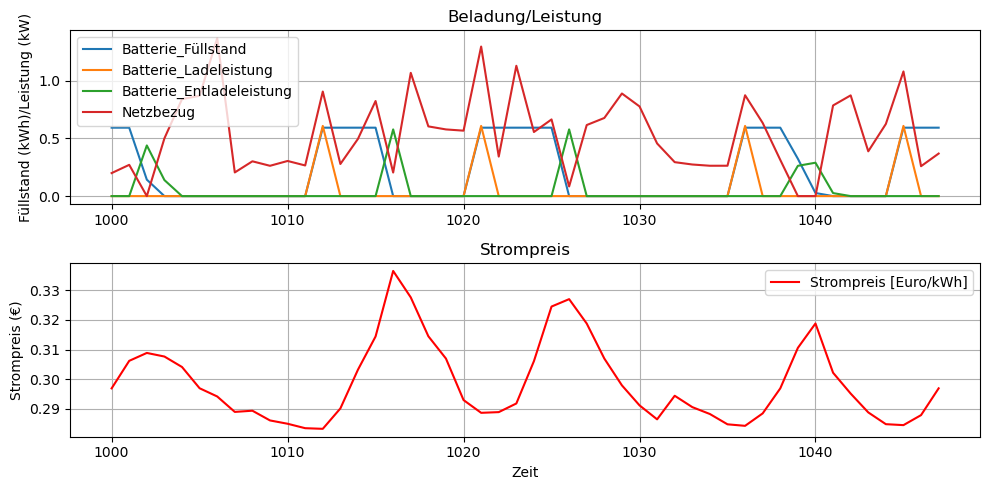

In [43]:
import matplotlib.pyplot as plt 

fig, axes = plt.subplots(nrows=2, figsize=(10, 5))

# Erstes Diagramm (df)
df[1000:1048].plot(ax=axes[0], legend=True, title="Beladung/Leistung")
axes[0].set_ylabel("Füllstand (kWh)/Leistung (kW)")
axes[0].grid(True)

# Zweites Diagramm (df_strompreis)
df_strompreis[1000:1048].plot(ax=axes[1], color="r", legend=True, title="Strompreis")
axes[1].set_ylabel("Strompreis (€)")
axes[1].grid(True)

# Gemeinsame X-Achse benennen
axes[1].set_xlabel("Zeit")

plt.tight_layout() 
plt.show()